In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("fetch_california_housing.xlsx - Sheet1.csv")


# PART A: Conceptual Questions


### 1.What is a Decision Tree Regressor and how does it make predictions?

##### A Decision Tree Regressor is a machine learning algorithm used to predict continuous values like salary, price, or temperature.

##### It works by:

##### 1.Splitting data into smaller groups using conditions.
##### 2.Choosing splits that reduce prediction error (MSE).
##### 3.Storing the average value in the final leaf nodes.

### 2.What does “variance reduction” mean in Decision Trees?
##### In Decision Tree Regression, variance reduction means splitting the data so that values in each group become more similar.

##### The tree chooses the split that reduces the spread (variance) of target values the most.

##### Lower variance = better and more accurate predictions.


### 3.Why do Decision Trees not require feature scaling?
##### Decision Trees do not require feature scaling because they split data based on conditions and comparisons, not distances.

### 4.Why do Decision Trees tend to overfit?
##### Decision Trees tend to overfit because they keep creating splits until they almost memorize the training data.

##### This makes the model:

##### very accurate on training data
##### but poor on new/test data

### 5.What role does the max_depth parameter play?
##### max_depth controls the maximum number of levels a Decision Tree can grow.

##### .Smaller depth → simpler model, less overfitting
##### .Larger depth → more complex model, higher chance of overfitting

### 6.What is bias vs variance in regression?
##### Bias and variance are two types of prediction errors in regression.

### Bias

##### Bias means the model is too simple and cannot learn patterns properly.

##### Causes underfitting
##### Training and testing accuracy both low

##### Example:
##### Using a straight line for highly curved data.

### Variance

##### Variance means the model is too complex and memorizes training data.

##### Causes overfitting
##### Training accuracy high, testing accuracy low


## PART B: Data Exploration


In [3]:
df.shape

(20640, 9)

In [4]:
['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude',
 'target']

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude',
 'target']

In [5]:
df.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41,6.984127,1.023810,322,2.555556,37.88,-122.23,4.526
1,8.3014,21,6.238137,0.971880,2401,2.109842,37.86,-122.22,3.585
2,7.2574,52,8.288136,1.073446,496,2.802260,37.85,-122.24,3.521
3,5.6431,52,5.817352,1.073059,558,2.547945,37.85,-122.25,3.413
4,3.8462,52,6.281853,1.081081,565,2.181467,37.85,-122.25,3.422


In [6]:
df.duplicated().sum()

np.int64(0)

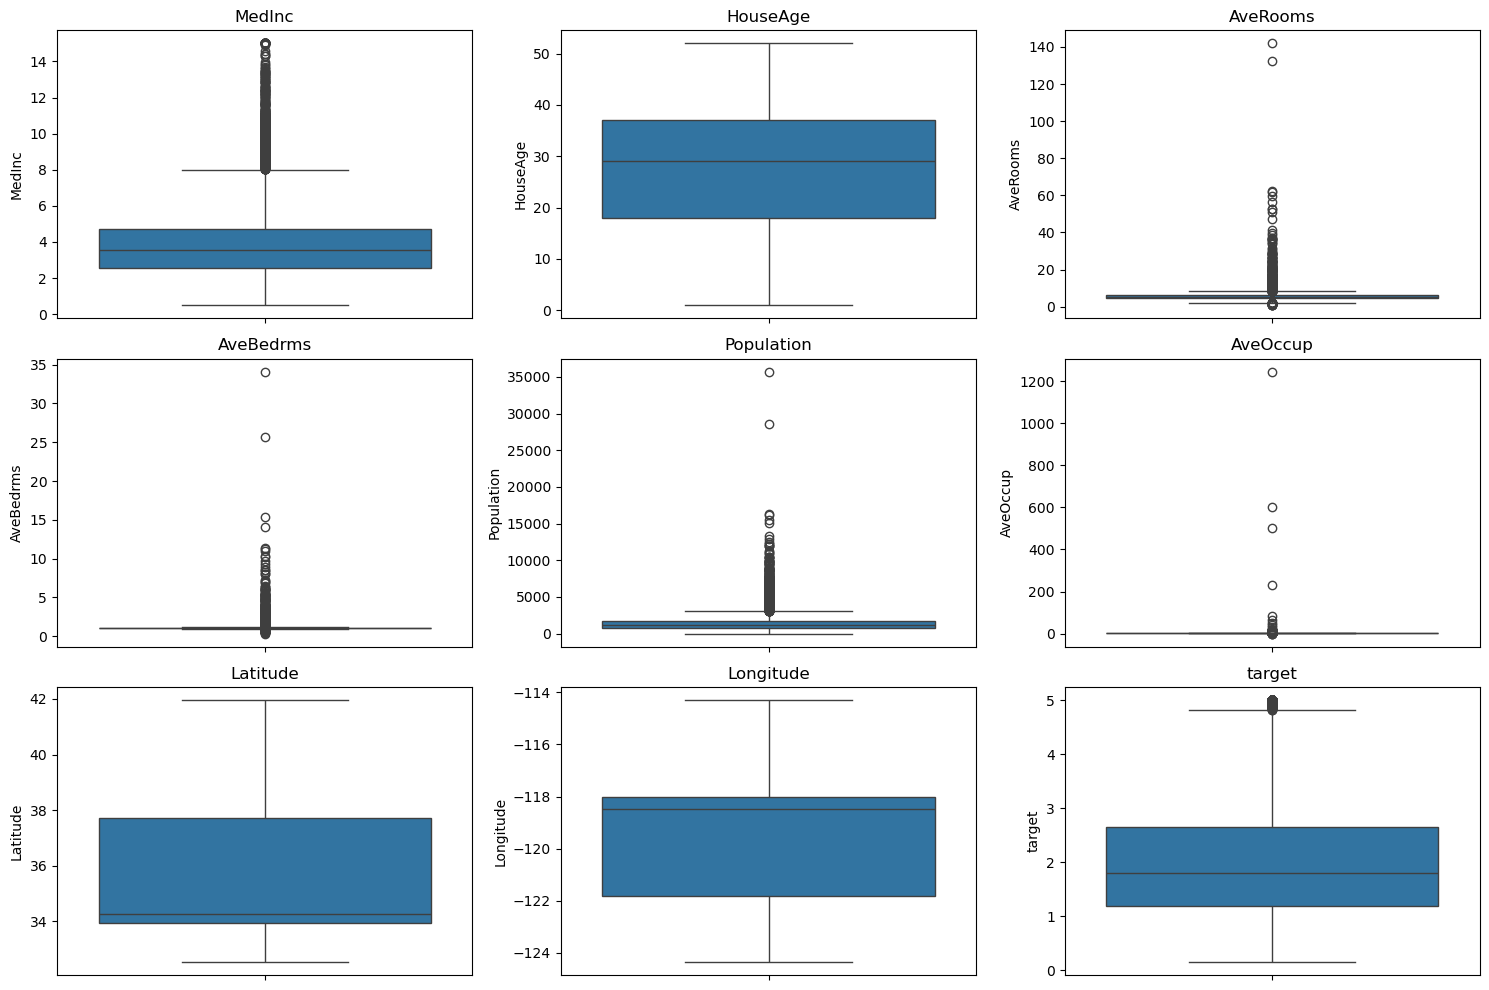

In [7]:
num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols):
    plt.subplot(3,3,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()
plt.show()

In [8]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

def cap_outliers(df, cols):
    df = df.copy()
    
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        df[col] = df[col].clip(lower, upper)
    
    return df

df= cap_outliers(df, num_cols)

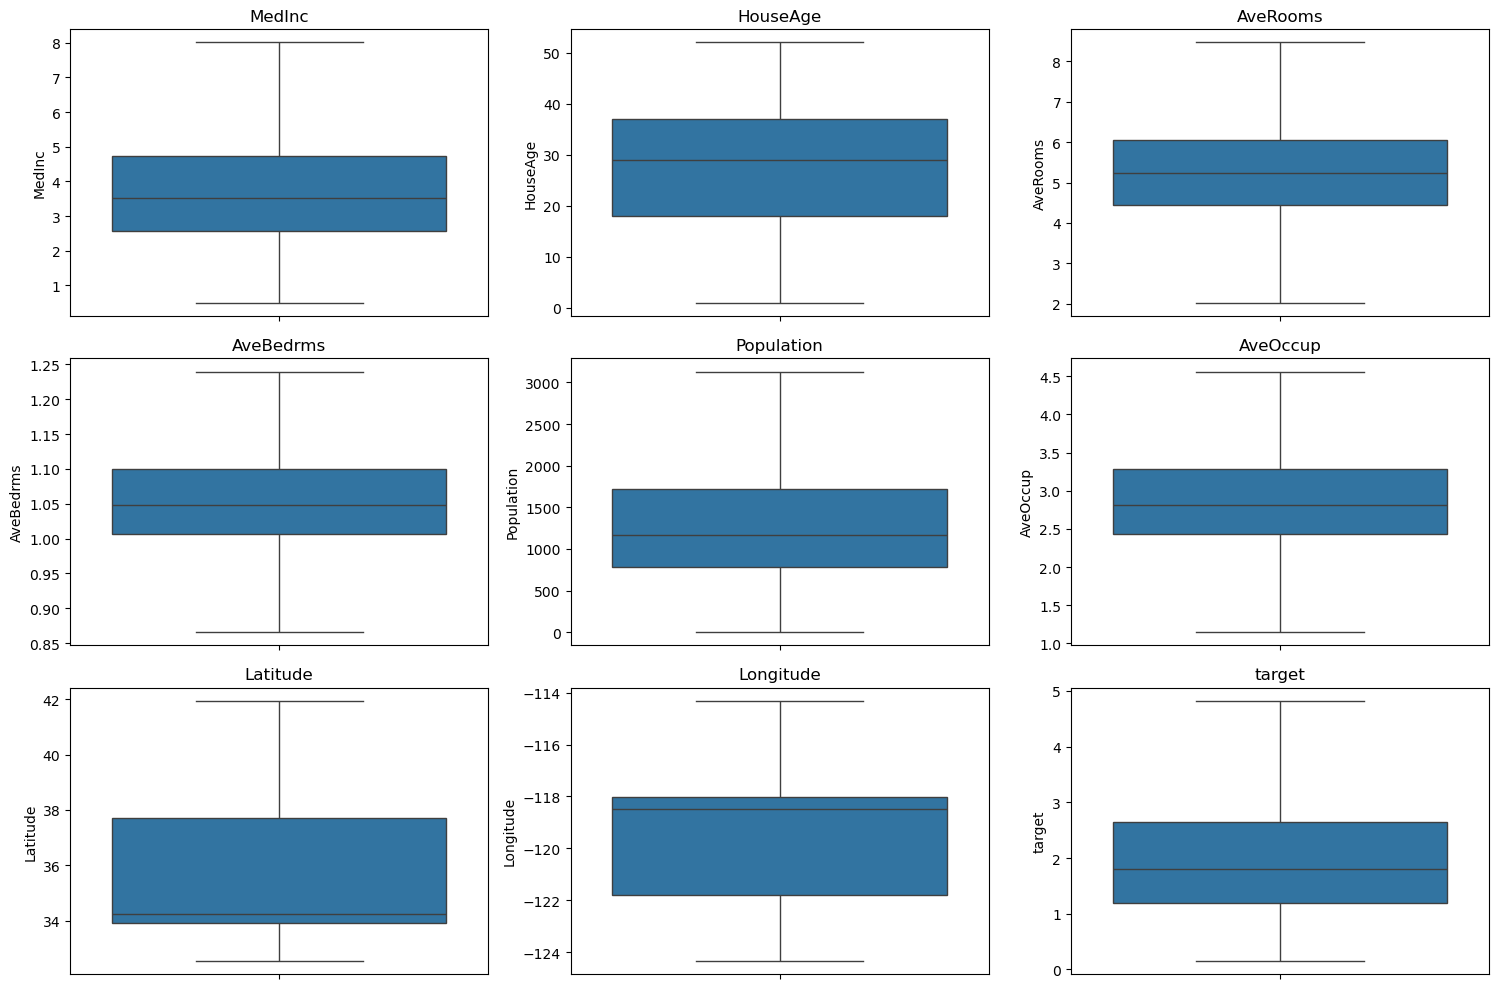

In [9]:
num_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols):
    plt.subplot(3,3,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()
plt.show()

## Identify:

In [10]:
y=df["target"]

In [11]:
x=df.drop(["target"],axis=1)

### Check and report:

In [12]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64

In [13]:
df.dtypes

MedInc        float64
HouseAge        int64
AveRooms      float64
AveBedrms     float64
Population      int64
AveOccup      float64
Latitude      float64
Longitude     float64
target        float64
dtype: object

In [14]:
from sklearn.feature_selection import mutual_info_regression

mf = mutual_info_regression(x, y)

mf = pd.Series(mf)
mf.index = x.columns

print(mf.sort_values(ascending=False))

Longitude     0.402117
MedInc        0.382898
Latitude      0.369948
AveRooms      0.102194
AveOccup      0.069375
AveBedrms     0.033155
HouseAge      0.031618
Population    0.017589
dtype: float64


In [15]:
x.drop(["HouseAge","Population"],axis=1,inplace=True)

## PART C: Data Preprocessing

##### Split the dataset:


In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

## PART D: Model Building


In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
params = {
    "criterion":['squared_error'],
    "splitter":("best","random"),
    "max_depth":(list(range(1,10))),
    "min_samples_split":[2,3,4,5,6,7],
    "min_samples_leaf":list(range(1,5))
}
tree_clf = DecisionTreeRegressor()
tree_cv = GridSearchCV(tree_clf,params,scoring = 'r2',n_jobs = -1 , verbose = 2 , cv = 5)

In [18]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(criterion='squared_error',random_state=42)

In [19]:
dt.fit(x_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [20]:
y_pred = dt.predict(x_test)

## PART E: Model Evaluation


In [21]:
from sklearn.metrics import mean_squared_error, r2_score
r2 = r2_score(y_test, y_pred)

print(r2)

0.648613550679165


In [22]:
mse = mean_squared_error(y_test, y_pred)

print(mse)

0.44427761688655504


In [23]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(rmse)

0.6665415342546592


In [24]:
train_score = dt.score(x_train, y_train)
test_score = dt.score(x_test, y_test)

print("Train Score:", train_score)
print("Test Score:", test_score)

Train Score: 1.0
Test Score: 0.648613550679165


In [25]:
train_r2 = dt.score(x_train, y_train)
test_r2 = dt.score(x_test, y_test)

print("Train R²:", train_r2)
print("Test R²:", test_r2)

Train R²: 1.0
Test R²: 0.648613550679165


### 1.Is the model overfitting or underfitting?

##### overfitting.

### 2.Compare train and test R².

##### 1.0 train R² = model memorized training data
##### lower test R² = weaker performance on unseen data

##### The gap is too large, which means the tree is too complex.

### 3.What does R² score indicate?

##### R² score (Coefficient of Determination) indicates how well a regression model explains the variation in the target variable.


## PART F: Understanding Tree Depth (Manual Experiment)


In [26]:
from sklearn.tree import DecisionTreeRegressor

depths = [3, 7, None]

for depth in depths:
    
    # Create model
    dt = DecisionTreeRegressor(max_depth=depth,random_state=42)
    
    # Train model
    dt.fit(x_train, y_train)
    
    # Scores
    train_r2 = dt.score(x_train, y_train)
    test_r2 = dt.score(x_test, y_test)
    
    print(f"max_depth = {depth}")
    print("Training R²:", train_r2)
    print("Testing R² :", test_r2)
    print("-" * 30)

max_depth = 3
Training R²: 0.5362145917318029
Testing R² : 0.5099745996281486
------------------------------
max_depth = 7
Training R²: 0.7177173854987144
Testing R² : 0.6593984739465814
------------------------------
max_depth = None
Training R²: 1.0
Testing R² : 0.648613550679165
------------------------------


### 1.What happens when the tree is very shallow?

##### This causes underfitting:
##### It generalizes better than a deep tree, but if it is too shallow, accuracy drops because important relationships are missed.

### 2.What happens when the tree is very deep?
##### The model becomes too complex and memorizes the training data

### 3.Which model performs best and why?
##### ✅ Best Model: max_depth = 7

## PART G: Tree Visualization

## PART H: Hyperparameter Comparison


In [28]:
from sklearn.tree import DecisionTreeRegressor

# Model 1: squared_error
dt1 = DecisionTreeRegressor(criterion='squared_error',min_samples_leaf=5,random_state=42)

dt1.fit(x_train, y_train)

print("Squared Error")
print("Train R²:", dt1.score(x_train, y_train))
print("Test R² :", dt1.score(x_test, y_test))


# Model 2: absolute_error
dt2 = DecisionTreeRegressor(criterion='absolute_error',min_samples_leaf=5,random_state=42)

dt2.fit(x_train, y_train)

print("\nAbsolute Error")
print("Train R²:", dt2.score(x_train, y_train))
print("Test R² :", dt2.score(x_test, y_test))

Squared Error
Train R²: 0.907325696354795
Test R² : 0.7175835303617202

Absolute Error
Train R²: 0.8669020194917489
Test R² : 0.6930704808149235


### 1.Which configuration gives better generalization?
##### squared_error

### Why?

##### The gap between training and testing scores is moderate, which means the model is learning useful patterns without severe overfitting.

## PART I: Reflection Questions


### 1.Why are Decision Trees suitable for housing price prediction?
##### Decision Trees are suitable for housing price prediction because they can handle:

##### nonlinear relationships
##### numerical and categorical features
##### complex decision patterns

### 2.What are the limitations of a single Decision Tree?
##### Limitations of a single Decision Tree:

##### 1.Overfitting
##### Deep trees memorize training data and perform poorly on new data.
##### 2.High Variance
##### Small changes in data can create a completely different tree.
##### 3.Lower Accuracy
##### Usually less accurate than ensemble models like Random Forest or XGBoost.
##### 4.Poor Generalization
##### Can struggle with unseen patterns if the tree is too complex.
##### 5.Greedy Splitting
##### Chooses the best split at each step locally, not globally optimal.
##### 6.Poor Extrapolation
##### Cannot predict values outside the training data range effectively

### 3.Why are ensemble methods preferred over a single tree?
##### Ensemble methods are preferred because they combine multiple trees to produce more accurate and stable predictions.

## PART J: Conclusion

### 1.What you learned about overfitting
##### I learned that overfitting happens when a model memorizes the training data instead of learning general patterns.

##### Signs of overfitting:

##### very high training score
##### much lower testing score

### 2.Importance of max_depth
##### max_depth is important because it controls how deep a Decision Tree can grow.

##### Small max_depth → simpler tree → may underfit
##### Large max_depth → complex tree → may overfit

### 3.Why hyperparameter tuning is important
##### Hyperparameter tuning is important because it helps improve model performance and generalization.